In [14]:
import torch
from torch import nn
print(torch.__version__)

2.10.0+cpu


In [15]:
weight = 0.7
bias = 0.3

X= torch.arange(0,10,0.1)
y = weight * X + bias
X[:10] ,y[:10]

(tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
         0.9000]),
 tensor([0.3000, 0.3700, 0.4400, 0.5100, 0.5800, 0.6500, 0.7200, 0.7900, 0.8600,
         0.9300]))

In [16]:
#Spliting the data
train_split = int(0.8* len(X))
X_train ,y_train  = X[:train_split],y[:train_split]
X_test ,y_test = X[train_split:] ,y[train_split:]

len(X_train), len(X_test),len(y_test),len(y_train)

(80, 20, 20, 80)

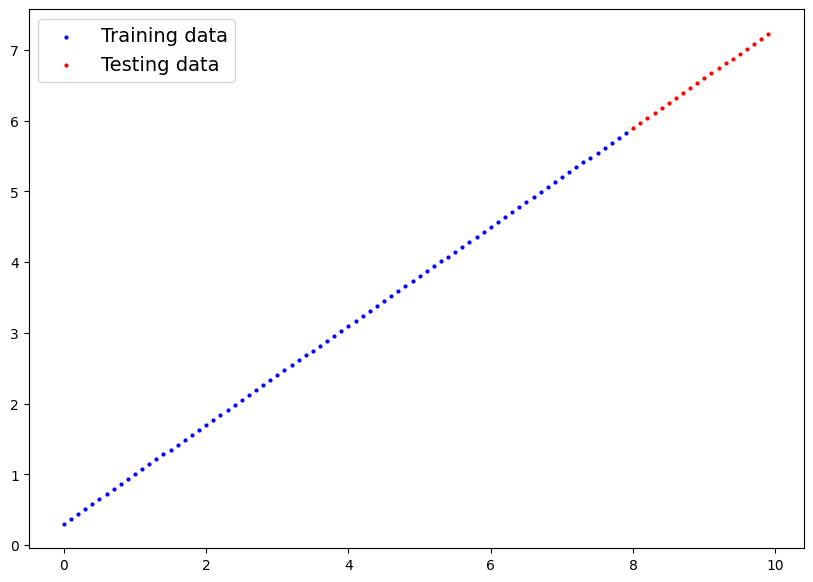

In [17]:
#Let's create a model to visualize it
import matplotlib.pyplot as plt
def plot_predictions(train_data = X_train, train_labels = y_train,test_data = X_test,test_labels=y_test, 
                     predictions=None):
    plt.figure(figsize=(10,7))
     # Plot training data in blue
    plt.scatter(train_data,train_labels,c="b",s=4,label = "Training data")
    #plot test data in green
    plt.scatter(test_data,test_labels,c="r",s=4,label = "Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",s=4,label = "Predictions")
        
    plt.legend(prop={"size":14})
    
plot_predictions() 

In [20]:
class LineraRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad = True, dtype = torch.float)) # without self variable becomes local variable
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype = torch.float))
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.weights*x + self.bias

In [25]:
torch.manual_seed(42)

model_0 = LineraRegression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
# List named parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
with torch.inference_mode():
    y_preds = model_0(X_test)
#torch.inference_mode() turns off a bunch of things (like gradient tracking, which is necessary for training but not for inference) to make forward-passes (data going through the forward() method) faster.

In [28]:
print(f"Number of testing sample:{len(X_test)}")
print(f"Number of predictions made:{len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing sample:20
Number of predictions made:20
Predicted values:
tensor([2.8223, 2.8560, 2.8897, 2.9233, 2.9570, 2.9907, 3.0243, 3.0580, 3.0917,
        3.1254, 3.1590, 3.1927, 3.2264, 3.2600, 3.2937, 3.3274, 3.3610, 3.3947,
        3.4284, 3.4620])
